In [2]:
import os 
import re
import glob
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from kinetic_function import (fit_function,
                              read_csv_file, 
                              read_csv_file_v2,
                              single_track_analysis,
                              autocorrelation,
                              # fit_autocorrelation,
                              # fit_autocorrelation_v2,
                              check_continuous_time,
                              # calculate_MSD,
                             )

In [3]:
%pdb

Automatic pdb calling has been turned ON


In [4]:
PROTEIN_SIZE = 1200
DELTA_T = 5.2

In [5]:
directory = "/home/u2175049/Downloads/"
paths = os.listdir(directory)
paths



['RN-20250304-BoundingBox_projection-xyz (2)_swap.ipynb',
 'preadx_cell_position_sib.pdf',
 'ParaView-5.13.0-MPI-Linux-Python3.10-x86_64',
 'Receipt071702200120241142071065572.png',
 '23K16_smob577_e1_align_rot_density-Spot.csv',
 'InteredgeDistance_v1.1_ImageJMacro.txt',
 'Result of 23K02_smob577_e1_align_rot_24.tif_merge_cp_masks.tif',
 'PCOMPBIOL-S-24-02277.pdf',
 '1-s2.0-S1097276523000333-mmc1.pdf',
 'Experiment-533-1 Tracking for quantification (time step 5,2seconds).csv',
 'main_reference.tex',
 'Solstice+Pattern+Bundle',
 'Result of 23K16_smob577_e1_align_rot_60.tif_merge_cp_masks.tif',
 'Wellcome_Full_ST.pdf',
 'main_save_modif.tex',
 'matlab_R2024b_Linux (1)',
 'RN-20250304-BoundingBox_projection-xyz (1).ipynb',
 'Curvature_induced_cellular_rearrangement.pdf',
 '020.tif',
 'Physics of Life 2025_hotel.pdf',
 '109.pdf',
 'WORKSHOP_MECHANOBIOLOGY.pdf',
 'OrganoidAnalysis_sarahmod2.py',
 'Image0003_o3_34hrs_1chan.tif',
 'exactccd.tar.gz',
 'poster_v2_a1.pdf',
 'image.png',
 '23K02

# Single track analysis

In [11]:
list_csv = glob.glob(directory+"/*).csv")

for csv in list_csv:
    if re.search("^(?!.*result).*$", csv,):
        print(csv)

        datas = read_csv_file(csv)
        # datas.groupby('TRACK ID').max()['FRAME'] - datas.groupby('TRACK ID').min()['FRAME']
        

/home/u2175049/Downloads/Experiment-533-1 Tracking for quantification (time step 5,2seconds).csv


In [12]:
DELTA_T = 5.2

In [13]:
datas.rename({"TRACK ID":"TRACK_ID",
             "T":"POSITION_T",
             "MEAN INTENSITY CH1":"MEAN_INTENSITY_CH1"}, 
             axis=1, 
             inplace=True)
datas


,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,CONTRAST_CH1,SNR_CH1
0,ID1888028,1888028,17,75.783470,158.476468,50.892260,0.0,115.46,23,0.5,1,1073.459459,1032.0,848.0,1490.0,39718.0,172.985965,0.095937,1.086435
1,ID1887775,1887775,17,72.312828,158.911445,50.022307,0.0,125.50,25,0.5,1,1054.972973,1002.0,833.0,1525.0,39034.0,167.119965,0.087492,1.015747
2,ID1887640,1887640,17,176.080170,155.431632,53.647112,0.0,50.20,10,0.5,1,1467.810811,1306.0,961.0,2444.0,54309.0,435.108341,0.159963,0.930417
3,ID1887515,1887515,17,142.084259,154.416687,51.327237,0.0,75.30,15,0.5,1,1339.810811,1155.0,911.0,2681.0,49573.0,459.872134,0.100533,0.532283
4,ID1887701,1887701,17,186.114243,154.416687,53.357128,0.0,20.08,4,0.5,1,1362.837838,1137.0,920.0,2768.0,50425.0,481.063204,0.185130,0.885083
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
467,ID1893416,1893416,794,133.927399,152.531788,56.111979,0.0,2369.44,472,0.5,1,1231.378378,1170.0,852.0,1888.0,45561.0,296.379107,0.152695,1.100737
468,ID1893480,1893480,794,131.639709,154.706671,55.677003,0.0,2489.92,496,0.5,1,1177.000000,1047.0,780.0,2163.0,43549.0,352.337906,0.149980,0.871343
469,ID1893483,1893483,794,99.367767,154.851664,55.532010,0.0,2469.84,492,0.5,1,1050.891892,1011.0,769.0,1532.0,38883.0,225.691749,0.127883,1.055892
470,ID1893412,1893412,794,76.446136,151.371851,58.286862,0.0,2344.34,467,0.5,1,1017.621622,973.0,723.0,1613.0,37652.0,181.476866,0.102720,1.044684


In [14]:
print(np.unique(datas["TRACK_ID"]))
datas.head()

[ 17 380 487 526 551 560 622 671 733 734 794]


,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,CONTRAST_CH1,SNR_CH1
0,ID1888028,1888028,17,75.783470,158.476468,50.892260,0.0,115.46,23,0.5,1,1073.459459,1032.0,848.0,1490.0,39718.0,172.985965,0.095937,1.086435
1,ID1887775,1887775,17,72.312828,158.911445,50.022307,0.0,125.50,25,0.5,1,1054.972973,1002.0,833.0,1525.0,39034.0,167.119965,0.087492,1.015747
2,ID1887640,1887640,17,176.080170,155.431632,53.647112,0.0,50.20,10,0.5,1,1467.810811,1306.0,961.0,2444.0,54309.0,435.108341,0.159963,0.930417
3,ID1887515,1887515,17,142.084259,154.416687,51.327237,0.0,75.30,15,0.5,1,1339.810811,1155.0,911.0,2681.0,49573.0,459.872134,0.100533,0.532283
4,ID1887701,1887701,17,186.114243,154.416687,53.357128,0.0,20.08,4,0.5,1,1362.837838,1137.0,920.0,2768.0,50425.0,481.063204,0.185130,0.885083


In [16]:
DELTA_T = 5.2


id_track = 17
(x, 
 y, 
 x_auto, 
 y_auto, 
 elongation_r, 
 translation_init_r,
 perr) = single_track_analysis(datas, 
                                 id_track, 
                                 delta_t = DELTA_T,
                                 protein_size=PROTEIN_SIZE,
                                 normalise_intensity=1,
                                 # normalize_auto=True,
                                 mm=None,
                                 lowpass_=False,
                                 cutoff=100,
                                 rtol=1e-5,
                                 method="original",
                                force_analysis=True,
                                  first_dot=True)
# (x, 
#  y_cutoff, 
#  x_auto, 
#  y_auto, 
#  elongation_r, 
#  translation_init_r) = single_track_analysis(datas, 
#                                              id_track, 
#                                              delta_t = DELTA_T,
#                                              protein_size=PROTEIN_SIZE,
#                                              normalise_intensity=1,
#                                              normalize=True,
#                                              lowpass_=True,
#                                              cutoff=100,)
print(elongation_r, translation_init_r)
print(perr)

184.73741776568974 0.07081427650699078
[1.27273678 3.16573917]


/home/u2175049/Documents/Code/KineticAnalysis/notebook/kinetic_function.py:470: UserWarning: Analysis is forced for track 17
  warnings.warn("Analysis is forced for track " + str(id_track),


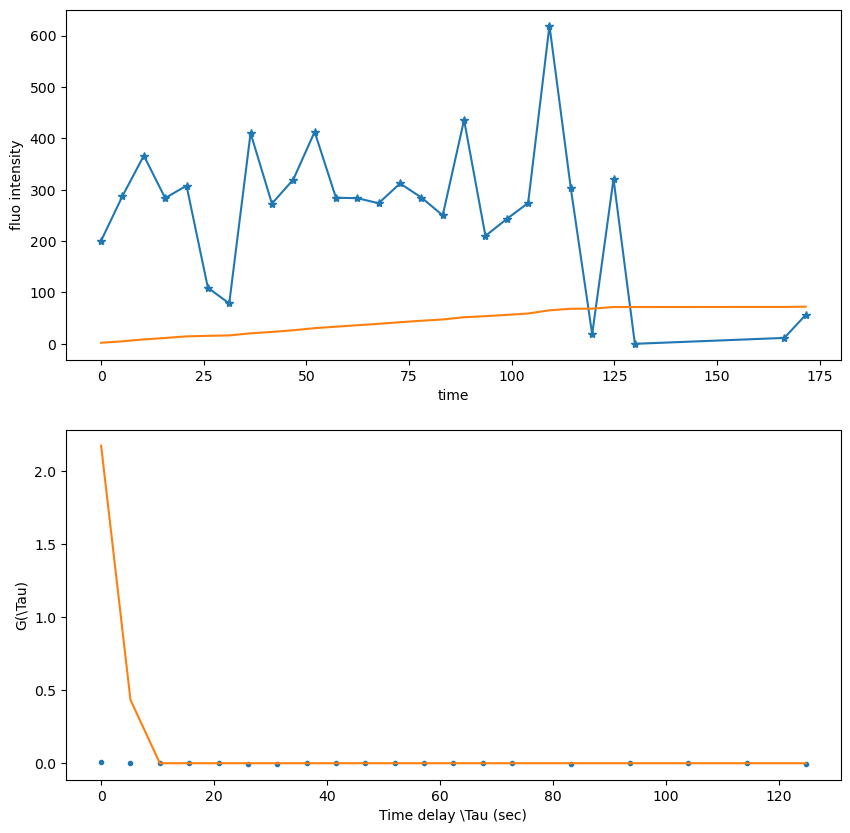

In [17]:
fig, ax = plt.subplots(2,1)

ax[0].plot(x, y-np.min(y), "*-")
# ax[0].plot(x,y_cutoff)
ax[0].set_xlabel("time")
ax[0].set_ylabel("fluo intensity")

ax[0].plot(x, (y-np.min(y)).cumsum(axis=0)/100)


ax[1].plot(x_auto, y_auto, '.')
ax[1].plot(x_auto, fit_function(x_auto, PROTEIN_SIZE/elongation_r, translation_init_r) )
ax[1].set_xlabel("Time delay \Tau (sec)")
ax[1].set_ylabel("G(\Tau)")
fig.set_size_inches((10,10))

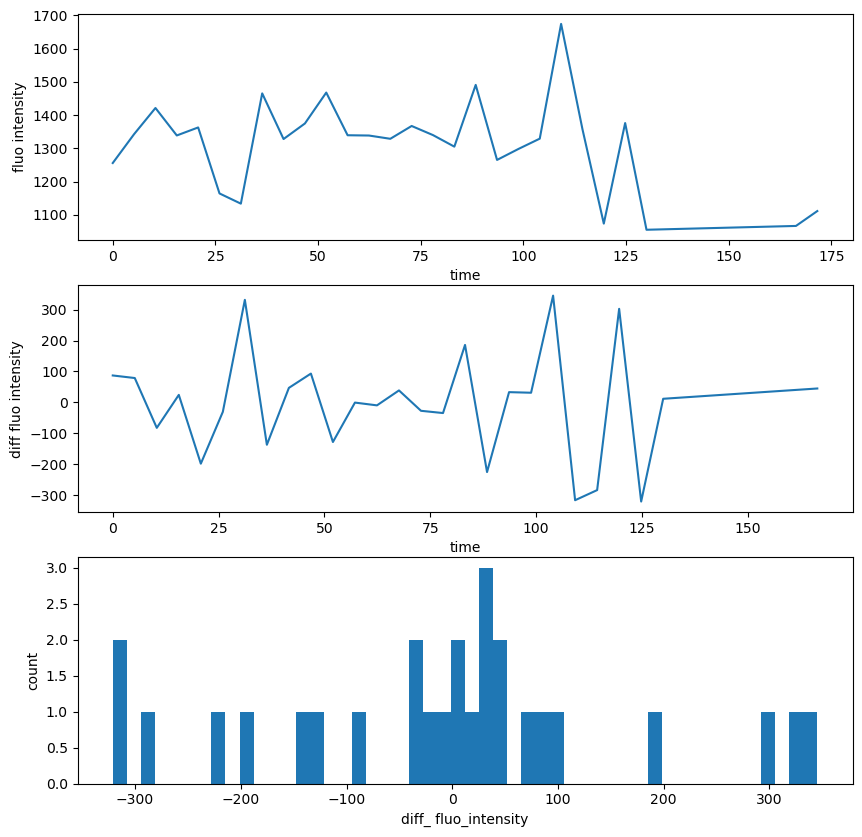

In [18]:
## difference between 2 time points
fig, ax = plt.subplots(3,1)
ax[0].plot(x,y)
ax[0].set_xlabel("time")
ax[0].set_ylabel("fluo intensity")

ax[1].plot(x[:-1], np.diff(y))
ax[1].set_xlabel("time")
ax[1].set_ylabel("diff fluo intensity")
_=ax[2].hist(np.diff(y), bins=50)
ax[2].set_ylabel("count")
ax[2].set_xlabel("diff_ fluo_intensity")
fig.set_size_inches((10,10))

Text(0, 0.5, 'intensity')

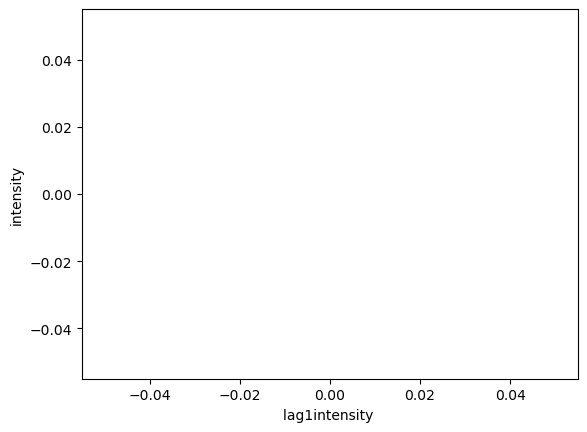

In [19]:
fig, ax = plt.subplots()
lag = 100
ax.plot(y[lag:], y[:-lag], '.')
ax.set_xlabel("lag1intensity ")
ax.set_ylabel("intensity")

In [20]:
DELTA_T

5.2

not fix
to fix


/home/u2175049/Documents/Code/KineticAnalysis/notebook/kinetic_function.py:305: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(func_,


not fix
to fix


/home/u2175049/Documents/Code/KineticAnalysis/notebook/kinetic_function.py:470: UserWarning: Analysis is forced for track 551
  warnings.warn("Analysis is forced for track " + str(id_track),
/home/u2175049/Documents/Code/KineticAnalysis/notebook/kinetic_function.py:470: UserWarning: Analysis is forced for track 622
  warnings.warn("Analysis is forced for track " + str(id_track),


not fix
not fix
not fix


/home/u2175049/Documents/Code/KineticAnalysis/notebook/kinetic_function.py:470: UserWarning: Analysis is forced for track 671
  warnings.warn("Analysis is forced for track " + str(id_track),
/home/u2175049/Documents/Code/KineticAnalysis/notebook/kinetic_function.py:470: UserWarning: Analysis is forced for track 733
  warnings.warn("Analysis is forced for track " + str(id_track),
/home/u2175049/Documents/Code/KineticAnalysis/notebook/kinetic_function.py:470: UserWarning: Analysis is forced for track 734
  warnings.warn("Analysis is forced for track " + str(id_track),


not fix
not fix
not fix


/home/u2175049/Documents/Code/KineticAnalysis/notebook/kinetic_function.py:470: UserWarning: Analysis is forced for track 794
  warnings.warn("Analysis is forced for track " + str(id_track),


not fix


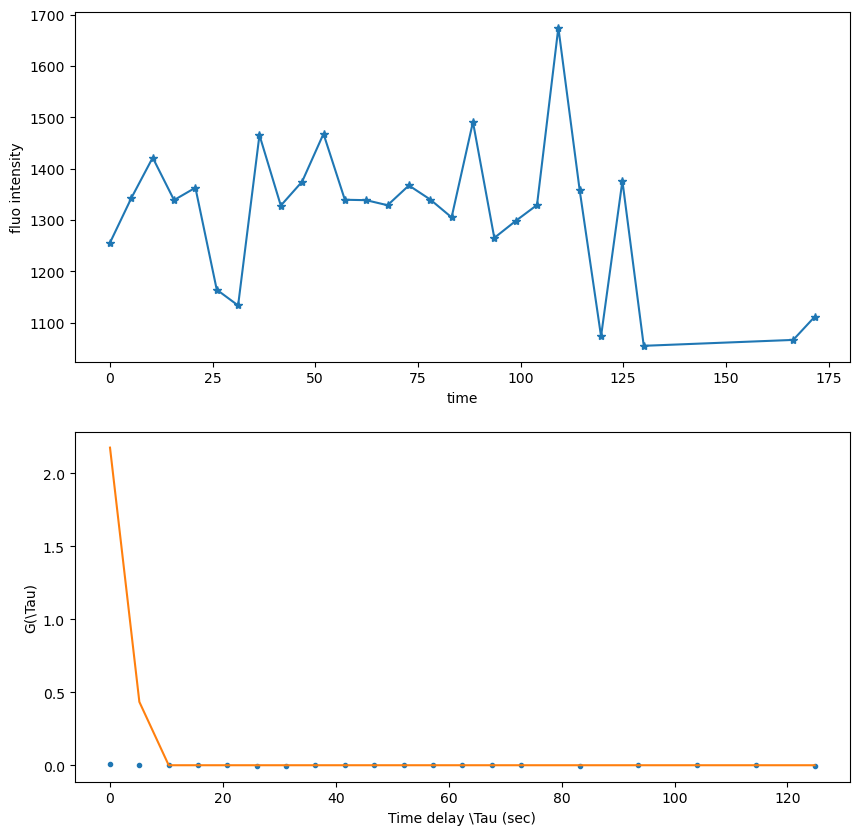

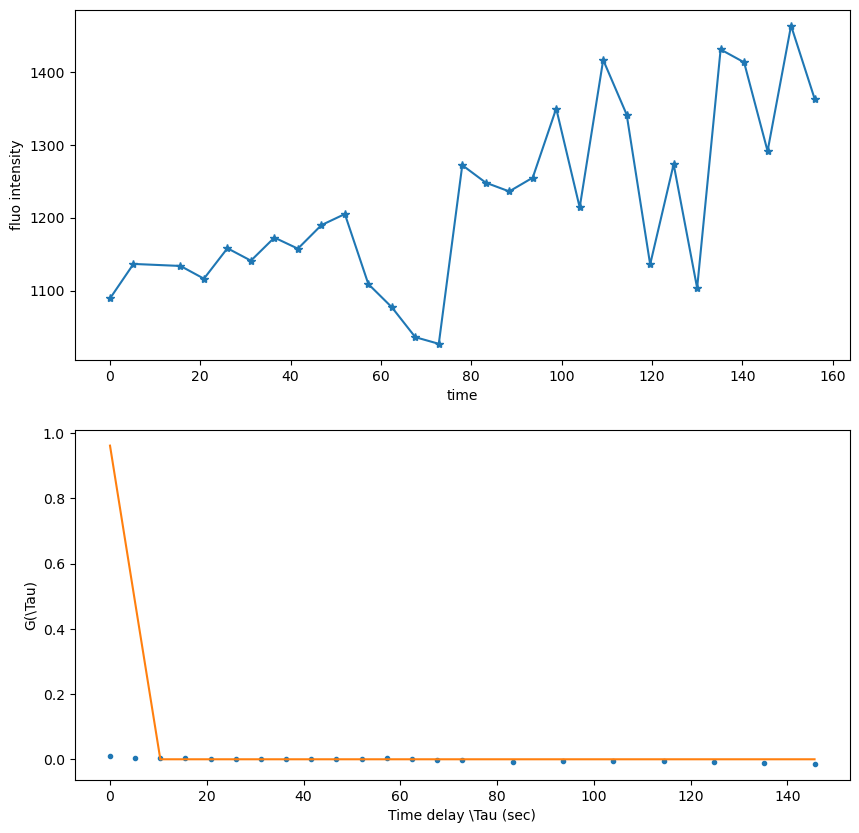

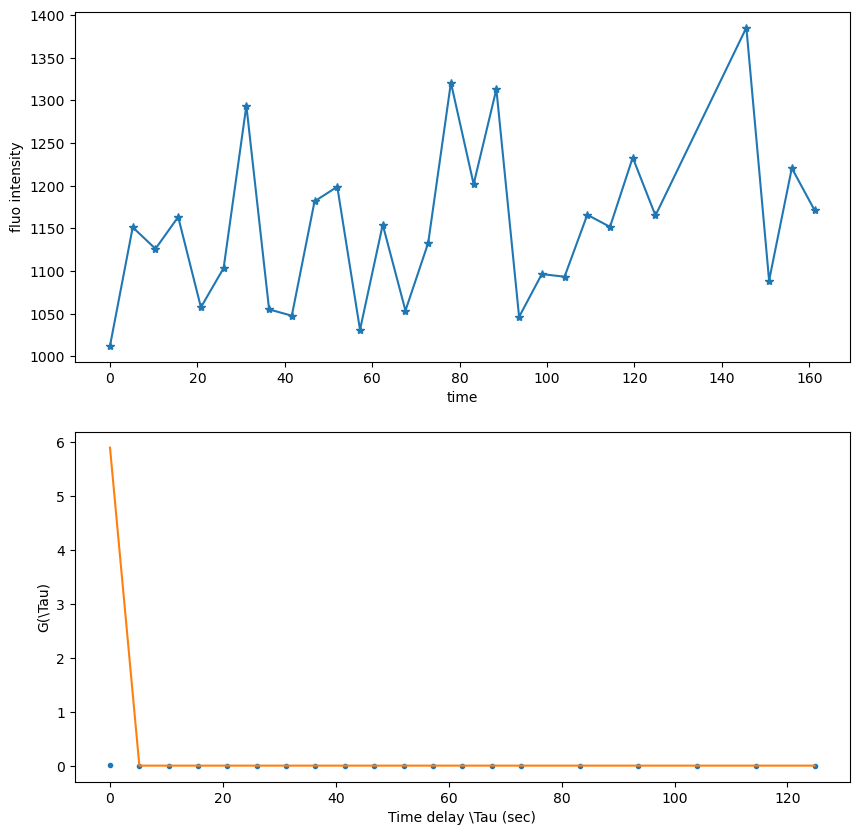

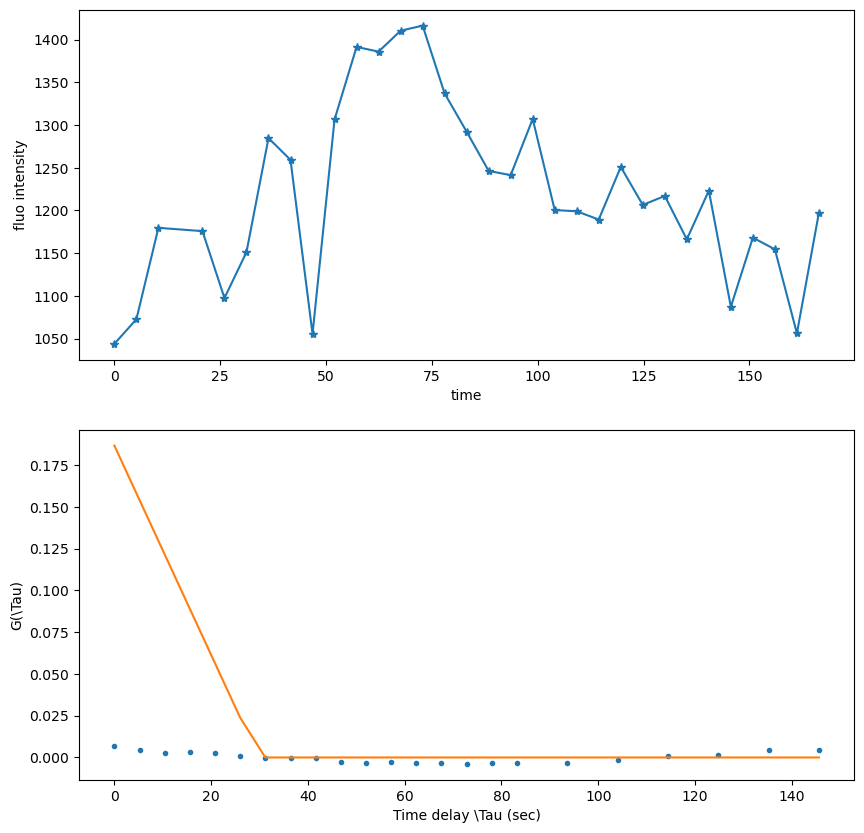

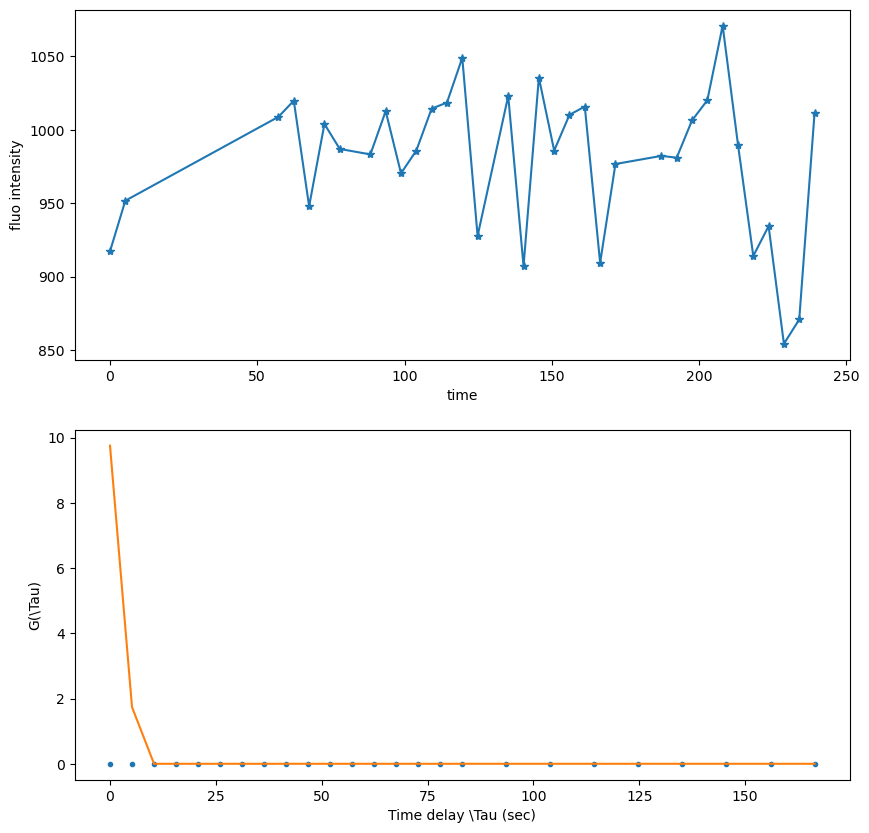

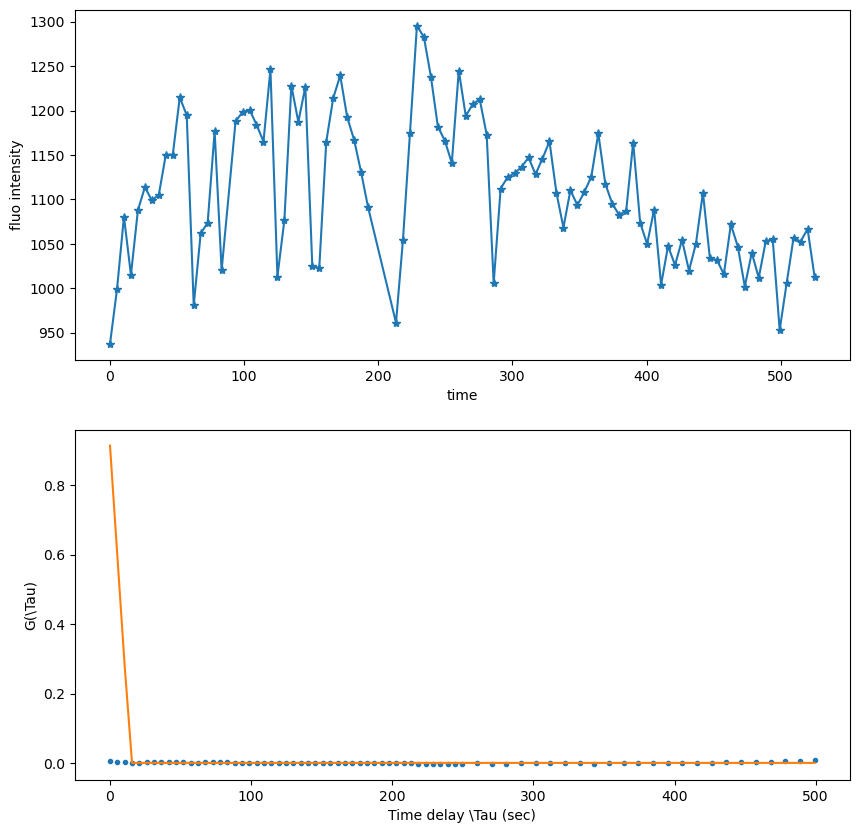

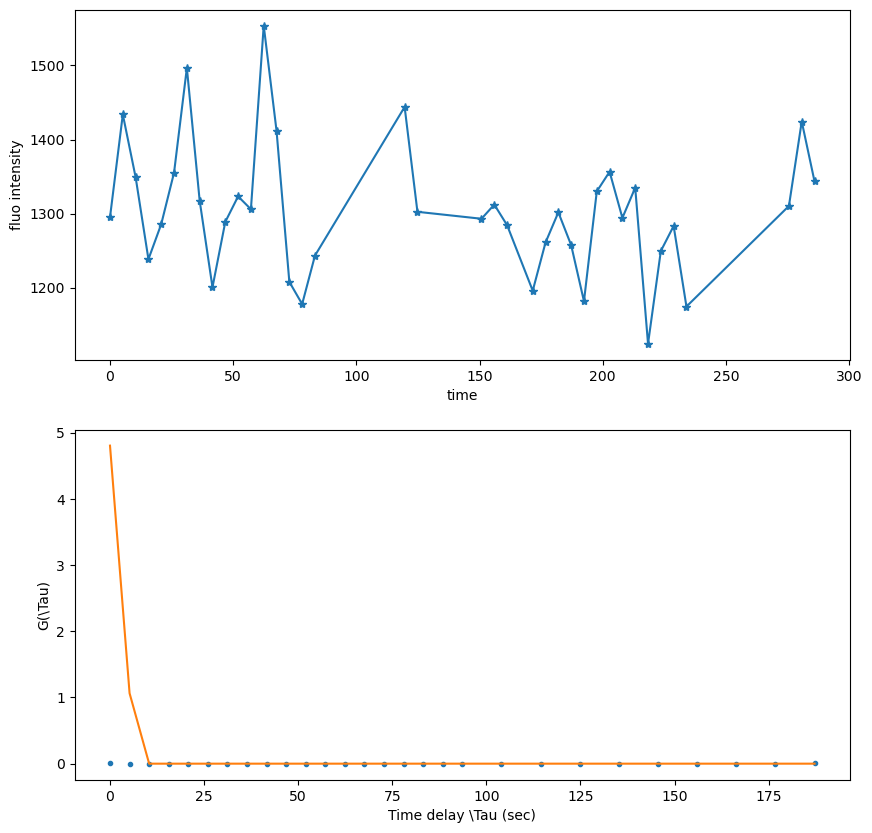

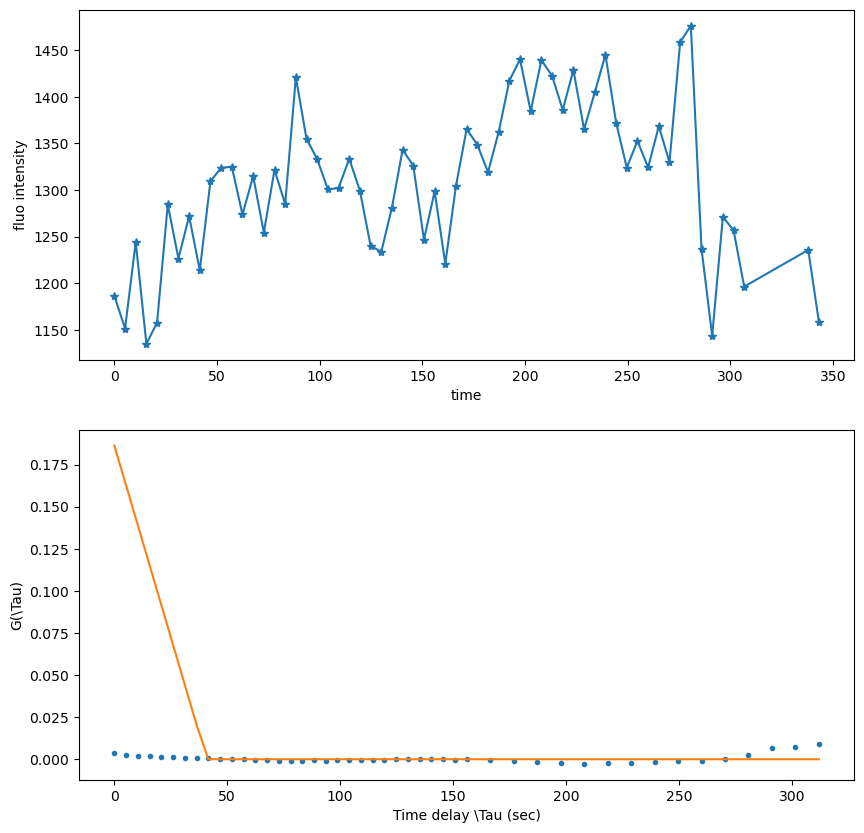

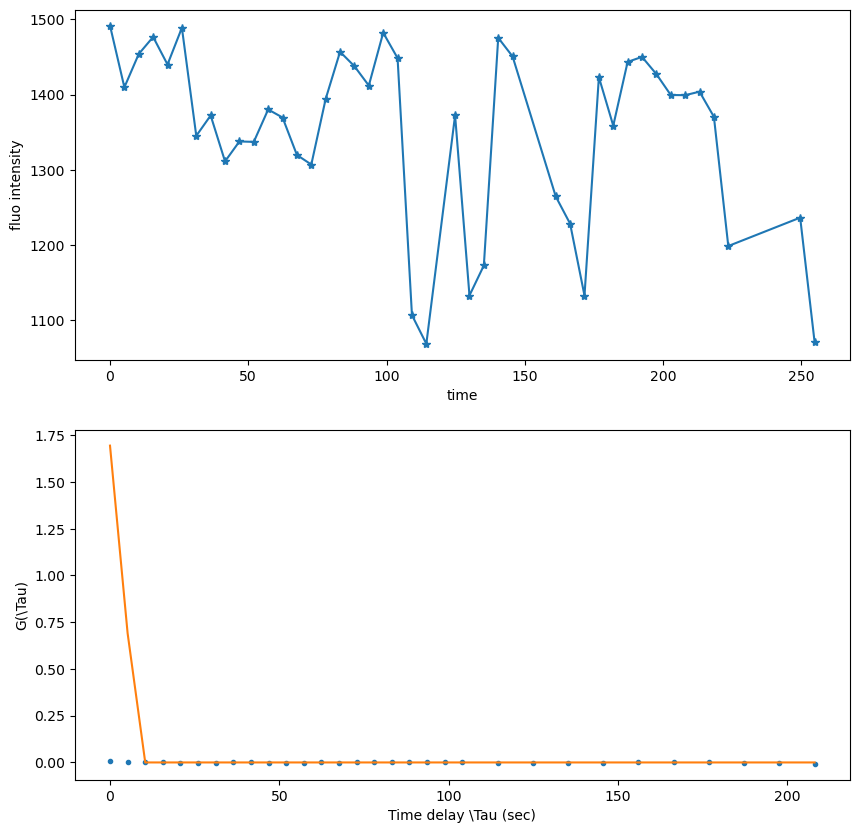

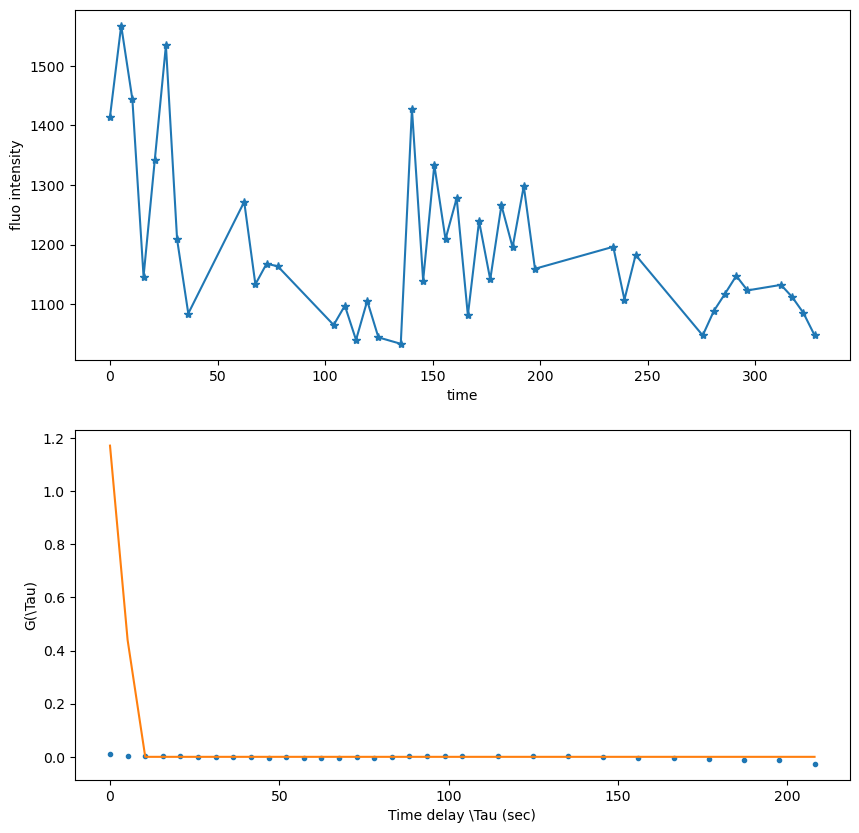

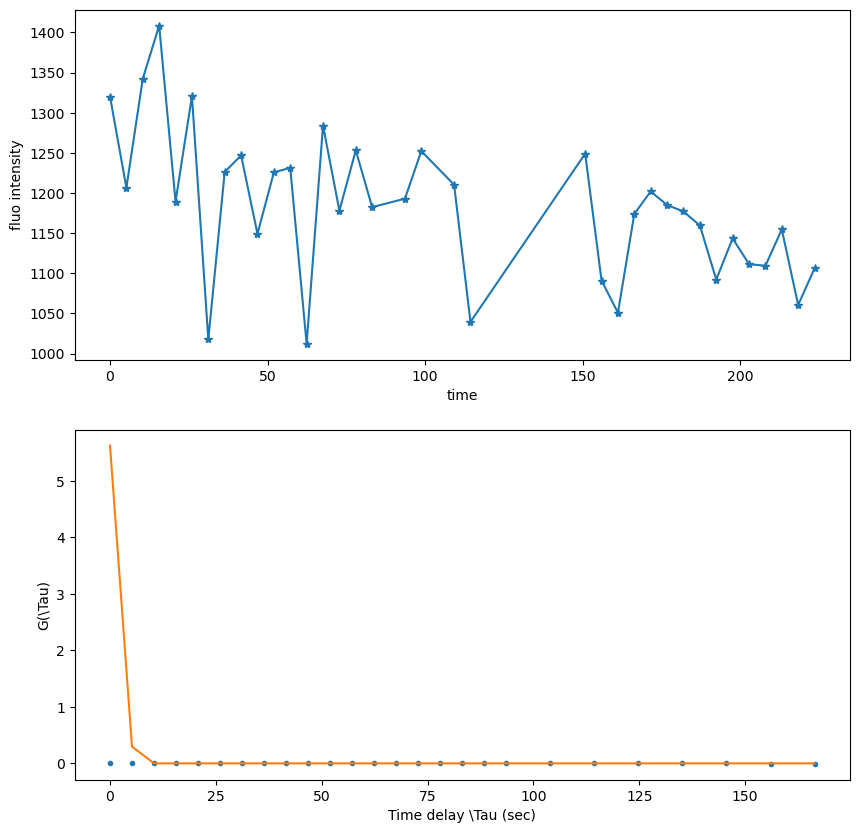

In [23]:
delta_t = DELTA_T
rtol=1e-5
for id_track in np.unique(datas.TRACK_ID):
    (x, 
     y, 
     x_auto, 
     y_auto, 
     elongation_r, 
     translation_init_r,
     perr) = single_track_analysis(datas, 
                                 id_track, 
                                 delta_t = DELTA_T,
                                 protein_size=PROTEIN_SIZE,
                                 normalise_intensity=1,
                                 # normalize_auto=True,
                                 mm=None,
                                 lowpass_=False,
                                 cutoff=100,
                                 rtol=1e-5,
                                 method="original",
                                 force_analysis=True,
                                 first_dot=True)
    
    normalise_intensity=1
    x = (datas[datas.TRACK_ID == id_track].sort_values('FRAME')['FRAME'].values -
         min(datas[datas.TRACK_ID == id_track].sort_values('FRAME')['FRAME'].values))*DELTA_T
    y = (datas[datas.TRACK_ID == id_track].sort_values('FRAME')['MEAN_INTENSITY_CH1'].values / normalise_intensity)

    if not check_continuous_time(x, delta_t, rtol=rtol):
        times_diff = np.diff(x)[np.where(np.isclose(np.diff(x), delta_t, rtol=rtol) == False)]
        if (times_diff < 3 * delta_t).all():
            print("to fix")
            i=0
            while i < (len(x)-1):
                if np.round(x[i]-x[i+1], decimals=2)>delta_t:
                    x = x[:i+1] + [(x[i]+x[i+1])/2] + x[i+1:]
                i+=1
        else:
            print("not fix")
            
        
    if x is not np.nan:
        fig, ax = plt.subplots(2,1)
        ax[0].plot(x,y, "*-")
        ax[0].set_xlabel("time")
        ax[0].set_ylabel("fluo intensity")

        ax[1].plot(x_auto, y_auto, '.')
        ax[1].plot(x_auto, fit_function(x_auto, PROTEIN_SIZE/elongation_r, translation_init_r) )
        ax[1].set_xlabel("Time delay \Tau (sec)")
        ax[1].set_ylabel("G(\Tau)")
        fig.set_size_inches((10,10))
        fig.savefig("img/"+str(id_track)+".png")

In [25]:
result = pd.DataFrame(columns=["track_id", "mean_x", "mean_intensity", "std_intensity"])
i = 0
for id_track in np.unique(datas.TRACK_ID):
    new_row = {"track_id":id_track,
               "mean_x":datas[datas.TRACK_ID == id_track].sort_values('FRAME')['Y'].mean(),
               "mean_intensity":(datas[datas.TRACK_ID == id_track].sort_values('FRAME')['MEAN_INTENSITY_CH1'].values).mean(),
               "std_intensity":(datas[datas.TRACK_ID == id_track].sort_values('FRAME')['MEAN_INTENSITY_CH1'].values).std()}
    result.loc[i] = new_row
    i+=1
    


KeyError: 'Y'

> /home/u2175049/anaconda3/lib/python3.11/site-packages/pandas/core/indexes/base.py(3812)get_loc()
   3810             ):
   3811                 raise InvalidIndexError(key)
-> 3812             raise KeyError(key) from err
   3813         except TypeError:
   3814             # If we have a listlike key, _check_indexing_error will raise



ipdb>  c


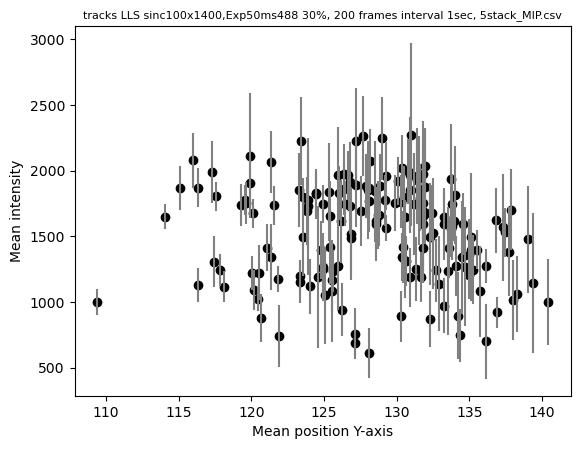

In [210]:
fig, ax = plt.subplots()

ax.scatter(result["mean_x"],result["mean_intensity"], c="black")
ax.errorbar(result["mean_x"],result["mean_intensity"], result["std_intensity"], fmt='none', c="grey", alpha=1)
ax.set_xlabel("Mean position Y-axis")
ax.set_ylabel("Mean intensity")
# ax.set_xlim(15,39)
_ = ax.set_title(csv.split('/')[-1], fontsize=8 )

In [56]:
df = datas

In [58]:
(df[df["TRACK_ID"] == 17].sort_values('FRAME')[
             'FRAME'].values -
         min(df[df["TRACK_ID"] == 17].sort_values('FRAME')[
                 'FRAME'].values))*5.2

array([  0. ,   5.2,  10.4,  15.6,  20.8,  26. ,  31.2,  36.4,  41.6,
        46.8,  52. ,  57.2,  62.4,  67.6,  72.8,  78. ,  83.2,  88.4,
        93.6,  98.8, 104. , 109.2, 114.4, 119.6, 124.8, 130. , 166.4,
       171.6])

In [74]:
for ii in np.unique(datas["TRACK_ID"]):
    print("track :", str(ii))
    print(np.diff(np.sort(datas[datas["TRACK_ID"]==ii]["FRAME"])))

track : 17
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 7 1]
track : 380
[1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
track : 487
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 4 1 1 1]
track : 526
[1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
track : 551
[ 1 10  1  1  1  1  2  1  1  1  1  1  1  1  2  1  1  1  1  1  1  1  3  1
  1  1  1  1  1  1  1  1  1]
track : 560
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 4
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
track : 622
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 7 1 5 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 8 1 1]
track : 671
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 6 1]
track : 733
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 3 1 1 1 1 1 1 1 1 1
 1 1 1 5 1]
track : 734
[1 1 1 1 1 1 1 5 1 1 1 5 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 

In [69]:
ysignvalue = np.sign(y_auto)
ysignvalue

array([ 1.,  1.,  1.,  1., -1.,  1.,  1., -1.,  1., -1.,  1.,  1., -1.,
        1.,  1., -1.,  1., -1., -1., -1., -1., -1., -1., -1., -1., -1.])

In [72]:
np.where(ysignvalue==-1)[0][0]

4

0.0007

# plot all track that was keep in result table

In [37]:

PROTEIN_SIZE = 1189

In [38]:
columns = ['file_name', 'track_id','len_track', 'elongation_time', 'init_translation_rate', "err_t", "err_c", "MSD"]
result = pd.DataFrame(columns=columns, dtype=float)
elongation_time=[]
translation_rate=[]

DELTA_T = 5.2
list_csv = glob.glob(directory+"/*).csv")
for csv in list_csv:
    if re.search("^(?!.*result).*$", csv,):
        
        datas = read_csv_file(csv)
        datas.rename({"TRACK ID":"TRACK_ID",
                     "T":"POSITION_T",
                     "MEAN INTENSITY CH1":"MEAN_INTENSITY_CH1"}, 
                     axis=1, 
                     inplace=True)




        for id_track in np.unique(datas['TRACK_ID']):

            (x, 
             y, 
             x_auto, 
             y_auto, 
             elongation_r, 
             translation_init_r,
             perr) = single_track_analysis(datas, 
                                         id_track, 
                                         delta_t = DELTA_T,
                                         protein_size=PROTEIN_SIZE,
                                         normalise_intensity=1,
                                         # normalize_auto=True,
                                         mm=None,
                                         lowpass_=False,
                                         cutoff=100,
                                         rtol=1e-1,
                                         method="original",
                                         force_analysis=True,
                                         first_dot=True)

            # MSDs = calculate_MSD(x = datas[datas.TRACK_ID == id_track].sort_values('FRAME')['X'].values,
            #                      y = datas[datas.TRACK_ID == id_track].sort_values('FRAME')['Y'].values,
            #                      z = datas[datas.TRACK_ID == id_track].sort_values('FRAME')['Z'].values)

            if elongation_r>5:
                d = pd.DataFrame.from_dict({"file_name":"",
                                            'track_id':id_track,
                                            'len_track': len(x),
                                            'elongation_time':elongation_r,
                                            'init_translation_rate':translation_init_r,
                                           "err_t": perr[0], 
                                            "err_c":perr[1],
                                           # "MSD":np.sum(MSDs)
                                           },
                                           orient='index').T
                result = pd.concat([result, d], ignore_index=True)


        result['tmp'] = 1
        result[["track_id","len_track","elongation_time","init_translation_rate"]].mean()

/home/u2175049/Documents/Code/KineticAnalysis/notebook/kinetic_function.py:470: UserWarning: Analysis is forced for track 17
  warnings.warn("Analysis is forced for track " + str(id_track),
/home/u2175049/Documents/Code/KineticAnalysis/notebook/kinetic_function.py:305: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(func_,
/home/u2175049/Documents/Code/KineticAnalysis/notebook/kinetic_function.py:470: UserWarning: Analysis is forced for track 551
  warnings.warn("Analysis is forced for track " + str(id_track),
/home/u2175049/Documents/Code/KineticAnalysis/notebook/kinetic_function.py:470: UserWarning: Analysis is forced for track 622
  warnings.warn("Analysis is forced for track " + str(id_track),
/home/u2175049/Documents/Code/KineticAnalysis/notebook/kinetic_function.py:470: UserWarning: Analysis is forced for track 671
  warnings.warn("Analysis is forced for track " + str(id_track),
/home/u2175049/Documents/Code/KineticAnalysis/n

In [40]:
result.to_csv(csv[:-4]+"_result.csv")
# result[(result["MSD"]<2)].to_csv((files[0][:-4]+"_result_filter_MSD2.csv"))

In [39]:
result.sort_values("track_id")

,file_name,track_id,len_track,elongation_time,init_translation_rate,err_t,err_c,MSD,tmp
0,,17,28,183.043991,0.070814,1.272737,3.165739,NaN,1
1,,380,30,114.558125,0.100138,12.652292,10.893899,NaN,1
2,,487,29,230.25266,0.032814,inf,inf,NaN,1
3,,526,32,39.899632,0.179827,11.240481,2.004933,NaN,1
4,,551,34,187.920388,0.016207,1.99799,22.813485,NaN,1
5,,560,98,79.382543,0.073021,8.142435,6.739005,NaN,1
6,,622,38,178.025137,0.031164,2.091659,11.231861,NaN,1
7,,671,62,29.073338,0.131265,22.030032,3.882524,NaN,1
8,,733,43,135.430664,0.067218,4.002383,6.387232,NaN,1
9,,734,42,142.865803,0.102553,7.675345,8.678086,NaN,1


not fix
force analysis
original method
to fix
original method
to fix
original method
to fix
original method
not fix
force analysis
original method
to fix
original method
to fix
original method
not fix
force analysis
original method
not fix
force analysis
original method
not fix
force analysis
original method
not fix
force analysis
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
not fix
force analysis
original method
to fix
original method
not fix
force analysis
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
not fix
force analysis
original method
to fix
original method
not fix
force analysis
original method
not fix
force analysis
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
not fix
force analysis
original method
to fix
original method
to fix
original method
not fix
force analysis
ori

/home/u2175049/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


not fix
force analysis
original method
to fix
original method
to fix
original method
not fix
force analysis
original method
to fix
original method
to fix
original method
not fix
force analysis
original method
not fix
force analysis
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
not fix
force analysis
original method
to fix
original method
to fix
original method
not fix
force analysis
original method
to fix
original method
to fix
original method
not fix
force analysis
original method
not fix
force analysis
original method
not fix
force analysis
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
not fix
force analysis
original method
to fix
original method
not fix
forc

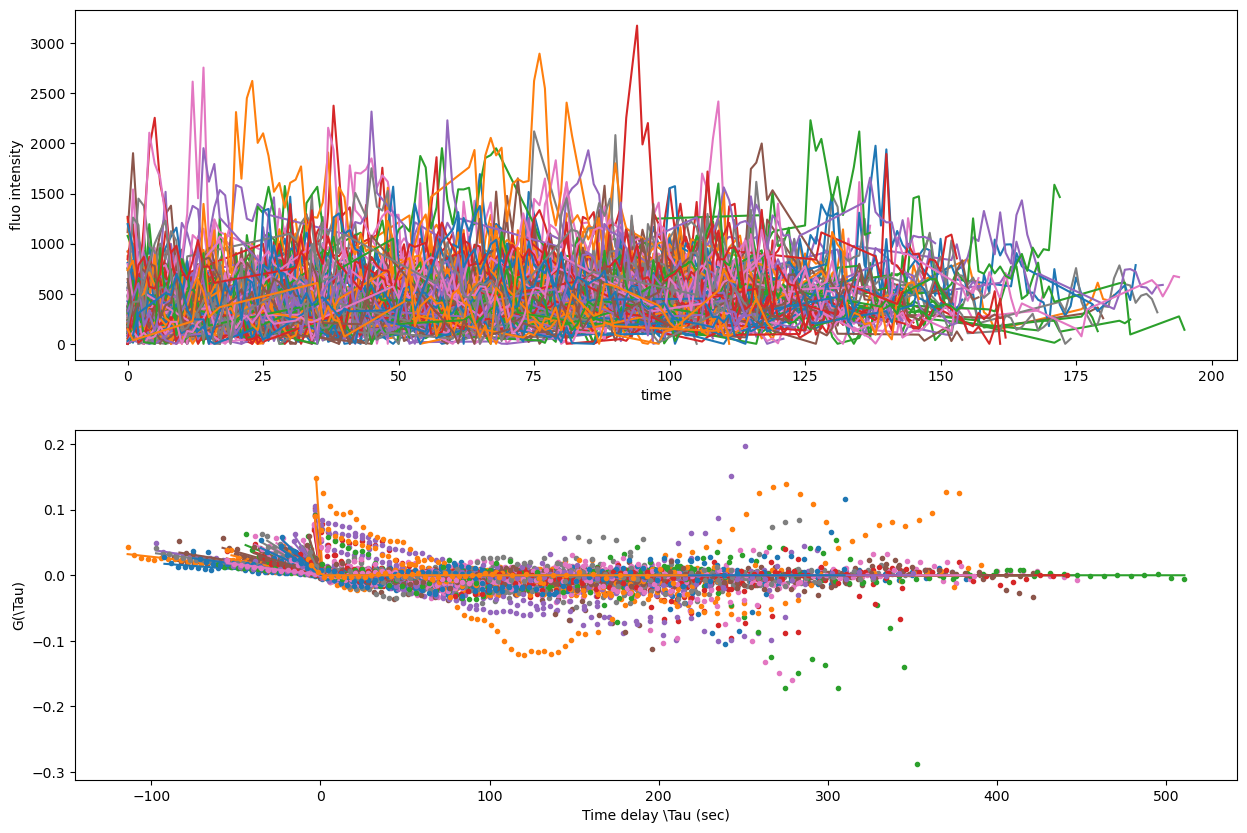

In [66]:
import matplotlib.colors as mcolors
fig, ax = plt.subplots(2,1)

colors = list(mcolors.TABLEAU_COLORS.keys())

i=0
for id_track in np.unique(result['track_id']):#[:5]:
# for id_track in [10,710,3021,7,16,8010,5471]:
# for id_track in [9353,19,5756,2881,11,6592,2092,1512,1754,6495,3108,1129,6350]:

    x = datas[datas.TRACK_ID==id_track].sort_values('FRAME')['POSITION_T'].values-min(datas[datas.TRACK_ID==id_track].sort_values('FRAME')['POSITION_T'].values)
    y = datas[datas.TRACK_ID==id_track].sort_values('FRAME')['MEAN_INTENSITY_CH1'].values-np.min(datas[datas.TRACK_ID==id_track].sort_values('FRAME')['MEAN_INTENSITY_CH1'].values)
    
    if len(x)>50:
        ax[0].plot(x, y, color=colors[i])


        (x, 
         y, 
         x_auto, 
         y_auto, 
         elongation_r, 
         translation_init_r,
         perr) = single_track_analysis(datas, 
                                     id_track, 
                                     delta_t = DELTA_T,
                                     protein_size=PROTEIN_SIZE,
                                     normalise_intensity=1,
                                     normalize_auto=True,
                                     mm=None,
                                     lowpass_=False,
                                     cutoff=100,
                                     rtol=1e-5,
                                     method="original",
                                     force_analysis=True,
                                     first_dot=True)


        ax[1].plot(x_auto-PROTEIN_SIZE/elongation_r, 
                   y_auto, 
                   '.', 
                   color=colors[i])
        ax[1].plot(x_auto-PROTEIN_SIZE/elongation_r, 
                   fit_function(x_auto, PROTEIN_SIZE/elongation_r, translation_init_r ), 
                   color=colors[i] )



        if i == 7:
            i=0
        else:
            i+=1

ax[0].set_xlabel("time")
ax[0].set_ylabel("fluo intensity")
ax[1].set_xlabel("Time delay \Tau (sec)")
ax[1].set_ylabel("G(\Tau)")
# ax[1].set_ylim(-0.002, 0.002)


fig.set_size_inches((15,10))
# print(len(np.unique(result['track_id'])))

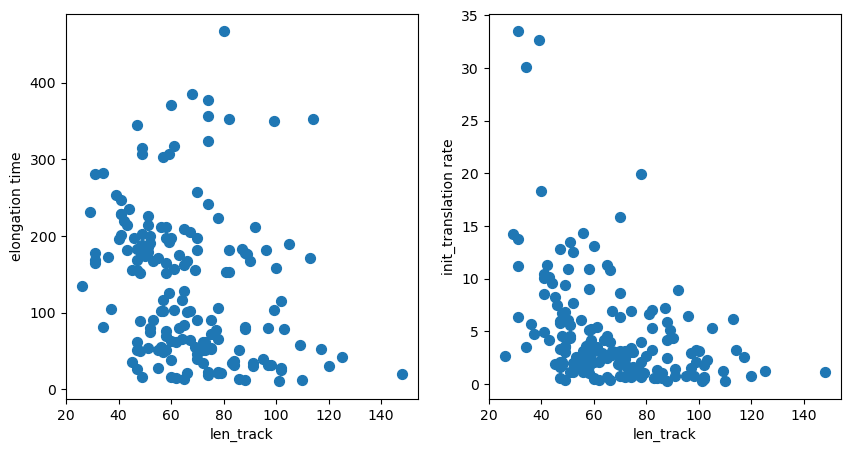

In [67]:
fig, ax = plt.subplots(1, 2)
ax[0].scatter(result['len_track'], result['elongation_time'], s=50)
ax[1].scatter(result['len_track'], result['init_translation_rate'], s=50)
ax[0].set_xlabel('len_track')
ax[0].set_ylabel('elongation time')

ax[1].set_xlabel('len_track')
ax[1].set_ylabel('init_translation rate')
fig.set_size_inches((10,5))

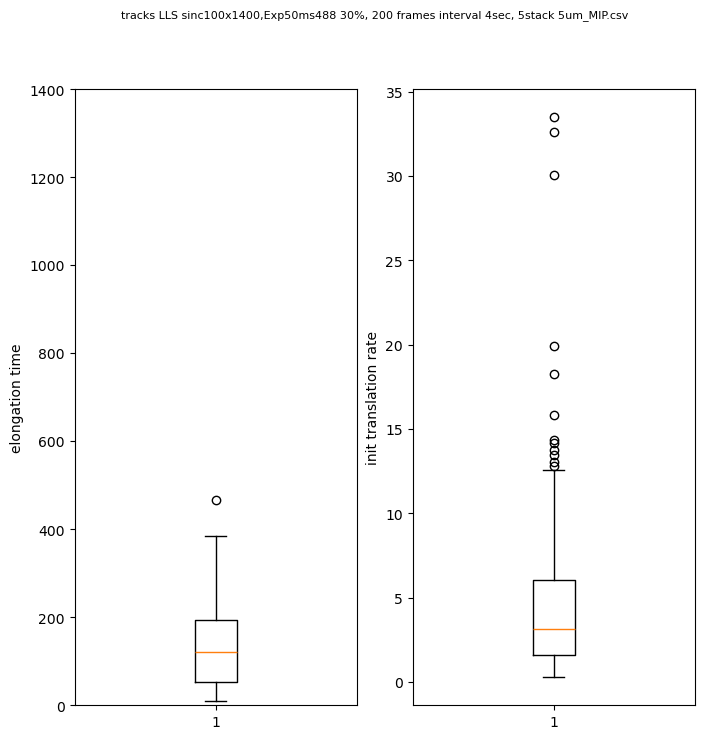

In [68]:
fig, ax = plt.subplots(1, 2)
ax[0].boxplot(result['elongation_time'].to_numpy())
ax[1].boxplot(result['init_translation_rate'].to_numpy())
ax[0].set_ylabel('elongation time')
ax[1].set_ylabel('init translation rate')
fig.set_size_inches((8,8))
ax[0].set_ylim(0,1400)

_ = fig.suptitle(files[0], fontsize=8 )

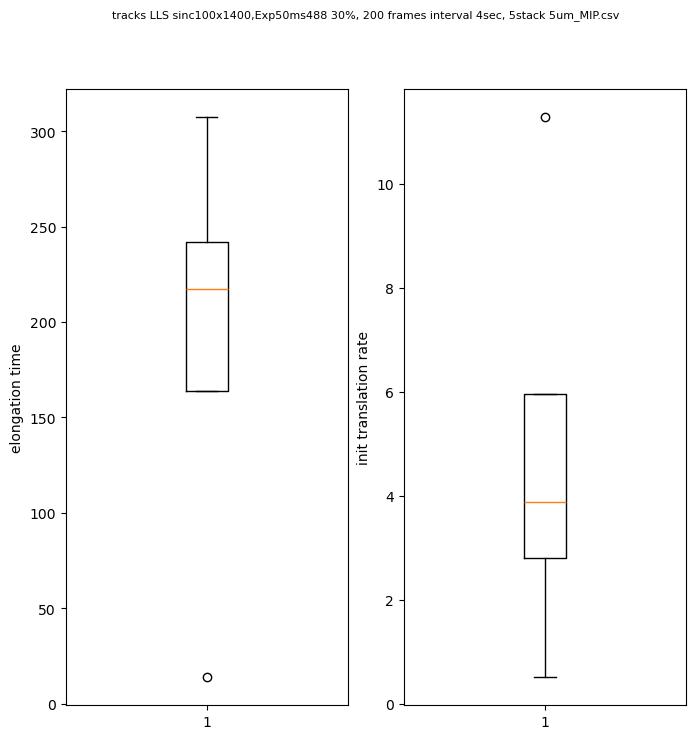

In [69]:

fig, ax = plt.subplots(1, 2)
ax[0].boxplot(result[(result["MSD"]<2) ]['elongation_time'].to_numpy())
ax[1].boxplot(result[(result["MSD"]<2)]['init_translation_rate'].to_numpy())
ax[0].set_ylabel('elongation time')
ax[1].set_ylabel('init translation rate')
fig.set_size_inches((8,8))
# ax[0].set_ylim(0,1400)

_ = fig.suptitle(files[0], fontsize=8 )

# Multiple file analysis

In [25]:
DELTA_T = 0.02174573
PROTEIN_SIZE = 1200

In [27]:
columns = ['file_name', 'track_id','len_track', 'elongation_time', 'init_translation_rate', "err_c", "err_t"]
result = pd.DataFrame(columns=columns, dtype=float)
elongation_time=[]
translation_rate=[]
for f in files:
    f = path+f
    datas = read_csv_file(f)


    for id_track in np.unique(datas['TRACK_ID']): 
        (x, 
         y, 
         x_auto, 
         y_auto, 
         elongation_r, 
         translation_init_r,
         perr) = single_track_analysis(datas, 
                                                     id_track, 
                                                     delta_t = DELTA_T,
                                                     protein_size=PROTEIN_SIZE,
                                                     normalise_intensity=1,
                                                     normalize_auto=True,
                                                     mm=None,
                                                     lowpass_=False,
                                                     cutoff=100,
                                                     rtol=1e-5,
                                                     method="original",
                                                    force_analysis=False)

        
        if elongation_r>5:
            d = pd.DataFrame.from_dict({'file_name':f.split('/')[-1],
                                        'track_id':id_track,
                                        'len_track': len(x),
                                        'elongation_time':elongation_r,
                                        'init_translation_rate':translation_init_r,
                                        'init_translation_rate':translation_init_r,
                                   "err_t": perr[0], 
                                    "err_c":perr[1]},
                                       orient='index').T
            result = pd.concat([result, d], ignore_index=True)



result['tmp'] = 1
# result.drop(result[result["len_track"]<100].index, inplace=True)

to fix
original method
original method
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
original method
to fix
original method
to fix
original method
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method
to fix
original method


In [28]:
# result.sort_values('len_track')
result

,file_name,track_id,len_track,elongation_time,init_translation_rate,err_c,err_t,tmp
0,DUP_Sun_100x1400_30-488_20msec_AFAP_190_track.csv,7,205,1317.24221,1563.382287,383.676136,0.226613,1
1,DUP_Sun_100x1400_30-488_20msec_AFAP_190_track.csv,10,267,633.313319,136.234798,15.446009,0.213499,1
2,DUP_Sun_100x1400_30-488_20msec_AFAP_190_track.csv,11,118,2352.270614,1851.102152,930.985647,0.255902,1
3,DUP_Sun_100x1400_30-488_20msec_AFAP_190_track.csv,16,192,1633.536754,1301.189145,262.813027,0.15015,1
4,DUP_Sun_100x1400_30-488_20msec_AFAP_190_track.csv,19,149,2851.235216,5895.043257,2240.281541,0.158268,1
...,...,...,...,...,...,...,...,...
145,DUP_Sun_100x1400_30-488_20msec_AFAP_190_t9_tra...,8351,117,2040.674423,1452.476147,236.143092,0.09331,1
146,DUP_Sun_100x1400_30-488_20msec_AFAP_190_t9_tra...,8388,113,1003.350812,2437.363685,1177.003736,0.585206,1
147,DUP_Sun_100x1400_30-488_20msec_AFAP_190_t9_tra...,9193,116,8438.89104,2994.762593,1116.157323,0.053371,1
148,DUP_Sun_100x1400_30-488_20msec_AFAP_190_t9_tra...,9746,112,7209.024606,9351.532459,1396.917395,0.025486,1


In [29]:
result.to_csv("/mnt/sda1/Sophie/2-KineticAnalysisData/2-Datas/02-Pierre/analysis.csv")

track_id                  4032.125000
len_track                  150.625000
elongation_time          19482.804586
init_translation_rate    58660.438013
tmp                          1.000000
dtype: float64


/tmp/ipykernel_366698/2862878632.py:7: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  print(result.mean())


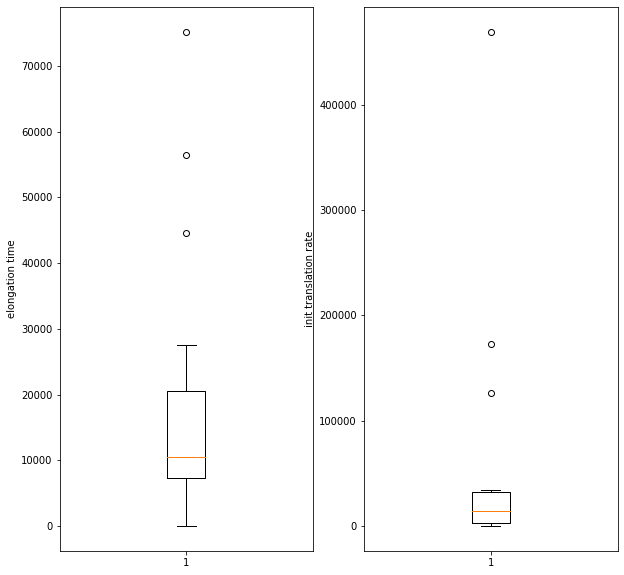

In [195]:
fig, ax = plt.subplots(1, 2)
ax[0].boxplot(result['elongation_time'])
ax[1].boxplot(result['init_translation_rate'])
ax[0].set_ylabel('elongation time')
ax[1].set_ylabel('init translation rate')
fig.set_size_inches((10,10))
print(result.mean())

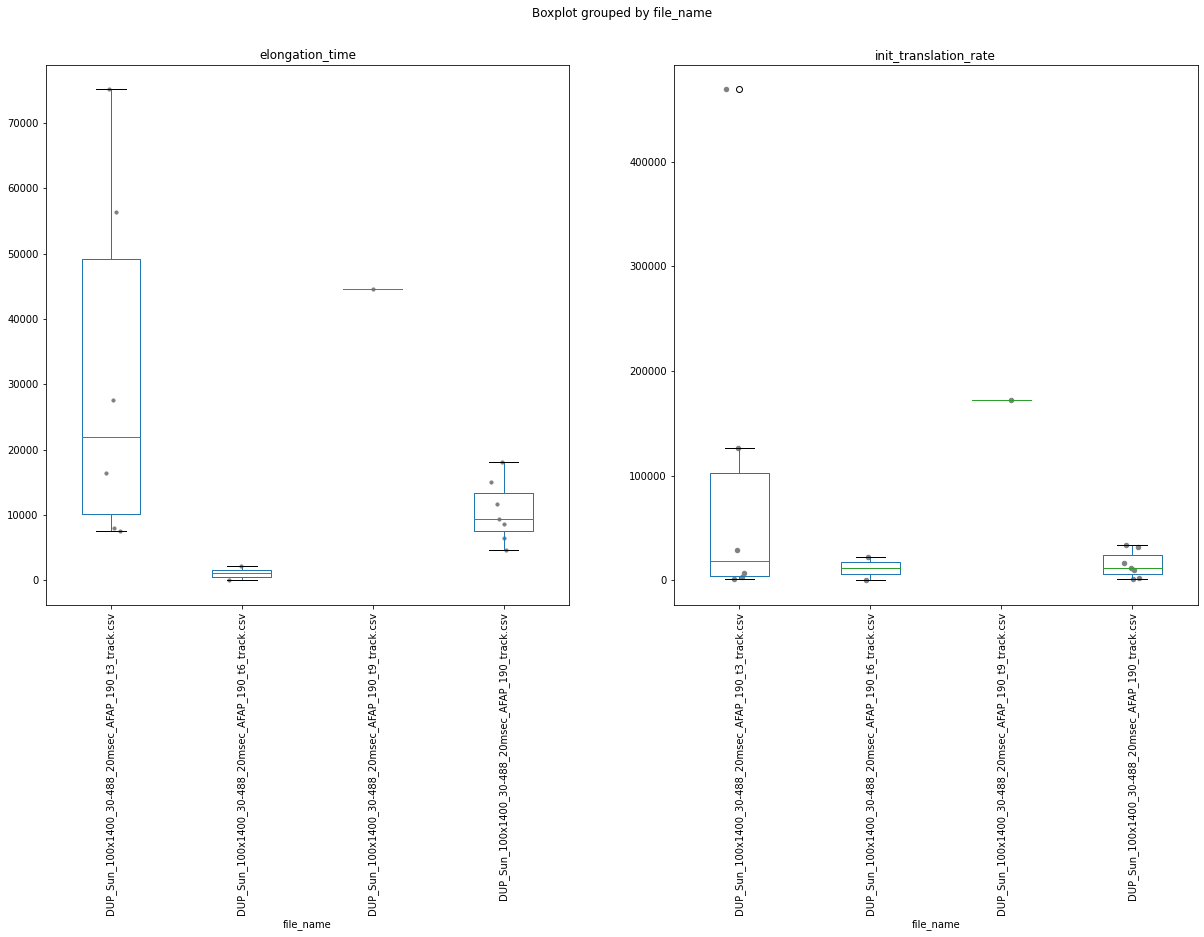

In [196]:
# result['elongation_time'] = pd.to_numeric(result['elongation_time'])
fig, ax = plt.subplots(1,2)
result.boxplot(['elongation_time'] , 
               by='file_name', 
               grid=False, 
               ax = ax[0],
               rot=90, 
              )

result.boxplot([ 'init_translation_rate'] , 
               by='file_name', 
               grid=False, 
               ax = ax[1],
               rot=90
               )

group = 'file_name'
column = 'elongation_time'
grouped = result.groupby(group)
names, vals, xs = [], [] ,[]
for i, (name, subdf) in enumerate(grouped):
    names.append(name)
    vals.append(subdf[column].tolist())
    xs.append(np.random.normal(i+1, 0.04, subdf.shape[0]))
clevels = np.linspace(0., 1., len(grouped))
for x, val, clevel in zip(xs, vals, clevels):
    ax[0].scatter(x, val, c='grey', alpha=1, s=10)
    
    
group = 'file_name'
column = 'init_translation_rate'
grouped = result.groupby(group)
names, vals, xs = [], [] ,[]
for i, (name, subdf) in enumerate(grouped):
    names.append(name)
    vals.append(subdf[column].tolist())
    xs.append(np.random.normal(i+1, 0.04, subdf.shape[0]))
clevels = np.linspace(0., 1., len(grouped))
for x, val, clevel in zip(xs, vals, clevels):
    ax[1].scatter(x, val, c='grey', alpha=1, s=20)
    
# ax[1].set_ylim(0,250)
fig.set_size_inches((20,10))

In [197]:
result.groupby(by='file_name')[['len_track','elongation_time', 'init_translation_rate']].mean()

,len_track,elongation_time,init_translation_rate
file_name,,,
DUP_Sun_100x1400_30-488_20msec_AFAP_190_t3_track.csv,122.666667,31851.439123,105996.340208
DUP_Sun_100x1400_30-488_20msec_AFAP_190_t6_track.csv,114.500000,1067.004762,11317.624959
DUP_Sun_100x1400_30-488_20msec_AFAP_190_t9_track.csv,109.000000,44568.529603,172373.790806
DUP_Sun_100x1400_30-488_20msec_AFAP_190_track.csv,190.857143,10559.099929,15368.560890


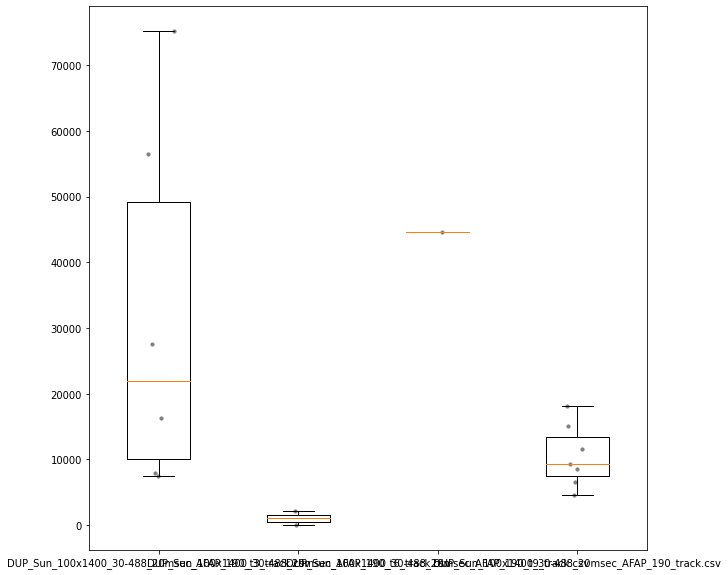

In [198]:
from matplotlib import cm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# initialize dataframe
# n = 200
# ngroup = 3
# df = pd.DataFrame({'data': np.random.rand(n), 'group': map(np.floor, np.random.rand(n) * ngroup)})
fig, ax = plt.subplots()

group = 'file_name'
column = 'elongation_time'
grouped = result.groupby(group)

names, vals, xs = [], [] ,[]

for i, (name, subdf) in enumerate(grouped):
    names.append(name)
    vals.append(subdf[column].tolist())
    xs.append(np.random.normal(i+1, 0.04, subdf.shape[0]))

ax.boxplot(vals, labels=names, )
ngroup = len(vals)



for x, val, clevel in zip(xs, vals, clevels):
    ax.scatter(x, val, c='grey', alpha=1, s=10)
    
ax.grid(False)
fig.set_size_inches((10,10))

In [199]:
result[["file_name", 'len_track','elongation_time', 'init_translation_rate']]

,file_name,len_track,elongation_time,init_translation_rate
0,DUP_Sun_100x1400_30-488_20msec_AFAP_190_track.csv,205,9318.07351,11914.330514
1,DUP_Sun_100x1400_30-488_20msec_AFAP_190_track.csv,267,4580.418322,989.748806
2,DUP_Sun_100x1400_30-488_20msec_AFAP_190_track.csv,192,11648.633438,9614.170446
3,DUP_Sun_100x1400_30-488_20msec_AFAP_190_track.csv,201,6529.842023,2621.069846
4,DUP_Sun_100x1400_30-488_20msec_AFAP_190_track.csv,150,8592.012892,16662.326354
5,DUP_Sun_100x1400_30-488_20msec_AFAP_190_track.csv,161,18147.536132,31855.077786
6,DUP_Sun_100x1400_30-488_20msec_AFAP_190_track.csv,160,15097.183184,33923.202475
7,DUP_Sun_100x1400_30-488_20msec_AFAP_190_t3_tra...,122,27602.012523,7137.752191
8,DUP_Sun_100x1400_30-488_20msec_AFAP_190_t3_tra...,164,7521.844156,726.496959
9,DUP_Sun_100x1400_30-488_20msec_AFAP_190_t3_tra...,159,8002.205743,3564.989263


In [200]:
result[["file_name", 'len_track','elongation_time', 'init_translation_rate']].mean()

/tmp/ipykernel_366698/1952775797.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  result[["file_name", 'len_track','elongation_time', 'init_translation_rate']].mean()


len_track                  150.625000
elongation_time          19482.804586
init_translation_rate    58660.438013
dtype: float64

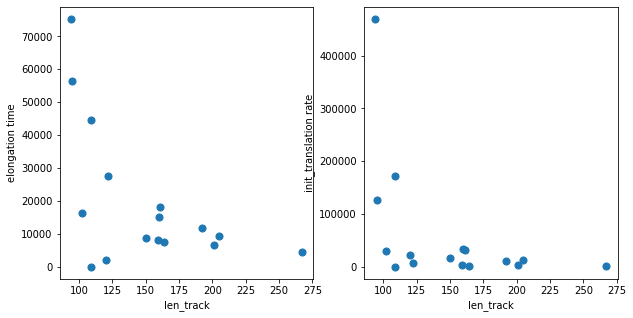

In [201]:
fig, ax = plt.subplots(1, 2)
ax[0].scatter(result['len_track'], result['elongation_time'], s=50)
ax[1].scatter(result['len_track'], result['init_translation_rate'], s=50)
ax[0].set_xlabel('len_track')
ax[0].set_ylabel('elongation time')

ax[1].set_xlabel('len_track')
ax[1].set_ylabel('init_translation rate')
fig.set_size_inches((10,5))

In [202]:
result["len_track"]*DELTA_T

0     0.615
1     0.801
2     0.576
3     0.603
4      0.45
5     0.483
6      0.48
7     0.366
8     0.492
9     0.477
10    0.285
11    0.282
12    0.306
13    0.327
14     0.36
15    0.327
Name: len_track, dtype: object